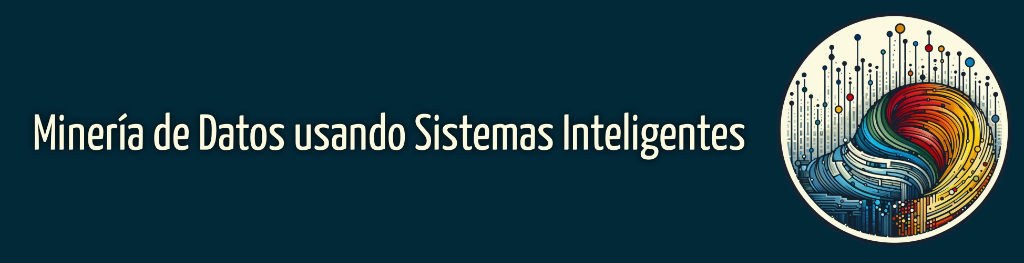



# PRACTICA 6

#  REGLAS DE ASOCIACIÓN

***Material de Lectura: Capítulo 9 del Libro Introducción a la Minería de Datos de Hernández Orallo***

**Ejercicios a entregar: 3b, 4a**

**NOTA: En los ejercicios en que utiliza código para obtener itemsets y reglas, en varios casos deberá bajar el valor de soporte mínimo o el mínimo de otra métrica (confianza, etc) para obtener todas las reglas resultantes.**

**Para resolver los ejercicios en código, puede generar reglas de asociación usando la [librería mlxtend](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/) en base a los itemsets generados con [Apriori](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/) o con [FPGrowth](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/).**


In [ ]:
#HELPER
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from collections import Counter
from itertools import chain,combinations
import itertools

base_url = "https://raw.githubusercontent.com/midusi/learning-datasets/refs/heads/main/"


In [ ]:
#HELPER
df_supermercado = pd.read_excel(base_url + "Supermercado.xlsx").rename(columns={"Unnamed: 0": "ID"})
df_compras = pd.read_csv(base_url + "compras.csv")
df_curso = pd.read_excel(base_url + "Curso1erAnio.xls", sheet_name="CursoNominal")

df_enfermedades = pd.read_excel('https://github.com/midusi/learning-datasets/raw/refs/heads/main/enfermedad.xlsx')

# 1. Conjuntos de items (itemsets)

a)  Dado un conjunto de datos con los items {A,B,C}, listar todos los posibles **itemsets** (subconjuntos no nulos de A,B,C) que pueden generarse y contarlos.

b)  Calcular la cantidad de **itemsets** máxima posible para cada fila de la tabla. Para los items A,B,C ya obtuvo el resultado en a).


| Items | #Items | Cantidad de **itemsets** máxima posible |
| --- | --- | --- |
| A | 1 | |
| A,B | 2 | |
| A,B,C | 3 | |
| A,B,C,D | 4 | |


c)  En base a la tabla de b), determinar la fórmula que calcula la cantidad de **itemsets** que pueden formarse en base a **N** items. Note la rapidez con la que se incrementa la cantidad de **itemsets** con respecto a la cantidad de items ¿qué impacto tiene esto en los algoritmos de generación de **itemsets**?

d)  En base al conjunto de datos de la tabla de abajo, listar los **itemsets** frecuentes que tienen un soporte mayor a 0.3. Para resolver este ejercicio, realizar una tabla con tantas columnas como **itemsets** posibles, y por cada **itemset** contar la cantidad de veces que aparece en la fila 1, y su soporte en la fila 2.


| id | Items |
| --- | --- |
| 1 | A,B,C,D |
| 2 | A,B |
| 3 | A,B |
| 4 | A,D |
| 5 | B |

Observe el número de **itemsets** resultante ¿cómo se compara con el máximo teórico calculado en a)?

e)  En lugar de usar un algoritmo de fuerza bruta como en d), aplique manualmente el algoritmo APriori para generar los itemsets frecuentes con soporte 0.3 o mayor. El resultado debe ser igual al del inciso d).




# 2. Reglas de asociación

a)  Dado un **itemset**, pueden generarse varias reglas de asociación a partir del mismo. Por ejemplo, para el itemset {A,B}, se pueden generar las reglas A→B y B→A. Calcule y cuente todas las reglas posibles a partir de un **itemset** de 3 elementos, como {A,B,C}.

b)  Dados los items A, B, C, liste y calcule la cantidad de reglas de asociación que pueden generarse para todos los **itemsets** posibles. Note que primero debe generar los **itemsets** de A, B, C como hizo en el ejercicio 1, y luego para cada itemset listar las reglas que se generan, y contar el total.

c)  Complete la tabla con la cantidad de **reglas** que pueden generarse a partir de los items de cada fila. El caso A,B,C ya lo calculó en el inciso b). Para el caso A,B,C,D deberá escribir un pequeño programa que liste todas las reglas posibles y luego las cuente (son muchas para listarlas a mano).


| Items | #Items | Cantidad de Reglas para todos los itemsets |
| --- | --- | --- |
| A | 1 | |
| A,B | 2 | |
| A,B,C | 3 | |
| A,B,C,D | 4 | |


d)  Note la rapidez con la que crece la cantidad de reglas con respecto a la cantidad de items. ¿Que implica esto para los algoritmos de generación de reglas?

e)  En base a los itemsets frecuentes generados en el ejercicio 1d) o 1e), genere todas las reglas posibles. Observe el número de reglas resultante. ¿Cómo se compara con el máximo teórico calculado en c)?

# 3. Métricas de evaluación de reglas

a)  Calcule manualmente el soporte, interés, cobertura y confianza de las reglas obtenidas en el inciso e) del ejercicio 2. Para ello, nuevamente recomendamos hacer una tabla con estos valores como filas y los itemsets como columnas. En base a los resultados, responda:


1.  ¿El valor del soporte es el mismo para X→Y o para Y→X?

2.  ¿Esto será cierto para cualquier regla? Analice la definición de soporte.

3.  ¿Se cumple lo mismo para la cobertura, la confianza y el interés?

 b)  En base a los datos de la tabla **enfermedad.xslx**, calcule manualmente el soporte, interés, y confianza de las siguientes:


| **Regla** | **Soporte** | **Cobertura** | **Confianza** | **Interés** |
| --- | --- | --- | --- | --- |
| Enfermedad → Antecedentes | | | | |
| Enfermedad → Adulto | | | | |
| Adulto → Enfermedad | | | | |
| Trabajo Pesado → Adulto | | | | |


Exprese los valores como **fracciones (no** utilice numeros con coma).

Responda:

1.  ¿Por qué es interesante la regla **Enfermedad → Antecedentes**, si bien su soporte y confianza son bajos?

2.  ¿Porqué varía la confianza entre **Adulto → Enfermedad** y **Enfermedad→Adulto**? ¿Varía el soporte en esos casos?

3.  ¿Que significa que **Trabajo Pesado → Adulto** tenga una cobertura y confianza relativamente altas, pero un interés bajo?



# 4. Evaluación de compras de supermercado

La tabla **Supermercado.xlsx** contiene información de las compras realizadas por 10 clientes distintos.

a)  Aplique **manualmente** el algoritmo APriori para generar los **itemsets** frecuentes con soporte mayor o igual a 0.3. Ordénelos en base a su soporte. **NOTA: para entregar este ejercicio, deberá incluir en la resolución (1) una tabla con el conjunto de itemsets finales y su soporte, y (2) la serie de tablas L~i~ y C~i~ como se indica en la resolución de la teoría, ordenadas de forma acorde. Para simplificar, puede utilizar la primer letra de cada item, por ejemplo V para Vino y y L para Leche.**

b)  Mediante código, utilizar FPGrowth para determinar los conjuntos de ítems frecuentes con soporte mayor o igual a 0.3. Verifique que obtiene los mismos itemsets que en a). .

c)  A partir de los conjuntos de ítems frecuentes conseguidos en el inciso b) construya reglas de asociación utilizando código. Seleccione del conjunto de reglas obtenido las dos mejores. Explique el criterio utilizado para realizar la selección.

d)  Calcule el valor del soporte, la cobertura, la confianza y el interés de las reglas: **SI Galletas y Bizcochos ENTONCES Miel** **SI Galletas y Miel ENTONCES Bizcochos** Compare los valores obtenidos en las cuatro métricas para las dos reglas anteriores. ¿Qué se puede concluir al respecto?




### 5. Evaluación de compras de un supermercado online

Los datos del archivo **compras.csv** contienen información de las categorías de productos llevados en 10000 compras de un supermercado online real[^1]. Para ayudar a los clientes en sus próximas compras, se busca generar reglas de asociación entre las categorías de productos, de forma que se puedan sugerir productos adicionales. Es decir, dadas las categorías A y B, y una regla A → B, si un cliente lleva A, entonces se le puede recomendar B.

a)  ¿Por qué las reglas con mayor interés no suelen tener como conclusión "Candy Chocolate"?

b)  Si el supermercado quiere generar sugerencias de categorías B, tal que estoy seguro que si el cliente lleva A entonces también necesita B ¿qué métrica debería priorizar?

c)  Si el supermercado quiere generar sugerencias de categorías con relevancia estadística (hay muchos casos de A→B) ¿qué métrica debería priorizar?

d)  Si el supermercado quiere generar sugerencias de categorías que actualmente no se venden mucho (B no se vende mucho) ¿qué métrica debería priorizar?

# 6. Reglas de Asociación adaptadas para clasificación

Construya reglas de asociación a partir de la información de la hoja **CursoNominal** perteneciente al archivo **Curso1erAnio.xls.** Para la identificación de los conjuntos de ítems frecuentes utilice un soporte mayor o igual a 0.25.

a)  Algunas reglas de asociación reglas se pueden utilizar como reglas de clasificación. Identifique las reglas que permitan clasificar los ejemplos según el atributo **RESULTADO**.

b)  Indique si todos los ejemplos se encuentran cubiertos por las reglas identificadas en el inciso **a)**; es decir, si todos los ejemplos cumplen al menos con el antecedente de alguna de las reglas. Justifique su respuesta.

c)  Calcule las métricas de soporte, cobertura, confianza e interés para las reglas identificadas en el inciso **a)**, ¿Qué métrica considera más apropiada para evaluar la capacidad de clasificación?


¹ Los datos originales están disponibles en **https://www.kaggle.com/c/instacart-market-basket-analysis**
